# Plot spatial-cell tuning matrices

Read any of the four `.rfmap` files saved by `spatial_cell_analysis.ipynb`: the full matrix or a 360° bearing curve for distance ≤8 cm, 8 < distance ≤16 cm, or distance >16 cm. Display a selected unit and an angular heatmap of units with nonzero responses, ordered as in `hd_rf_comparison.ipynb`. Run with the remote `~/.virtualenvs/rfmapping` kernel on `hhw9l84`.


In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from IPython.utils.capture import capture_output
from Utils.plotting import LIGHT_PLOT_STYLE, plot_keyed_heatmap
from Utils.rfmap import load_rf_maps, plot_2d_rfmap


In [2]:
result_path = Path(
    "/mnt/senzailab/Kai/#Recording/m19/260827/260827_12"
    "/data/spatial_cells/ProbeA/baseline/egocentric_rate_map_0-8.rfmap"
)
rf_maps = load_rf_maps(result_path)
print(f"Available units: {rf_maps.unit_ids}")


Available units: [3, 5, 6, 7, 9, 11, 12, 14, 16, 19, 24, 26, 27, 29, 32, 38, 39, 40, 43, 47, 50, 59, 60, 64, 74, 75, 76, 78, 79, 82, 86, 87, 94, 104, 105, 108, 111, 112, 116, 117, 123, 124, 128, 130, 134, 135, 136, 140, 146, 147, 149, 154, 157, 159, 161, 166, 169, 170, 177, 178, 182, 185, 186, 189, 191, 196, 200, 201, 202, 206, 209, 215, 218, 220, 221, 224, 226, 229, 232, 233, 234, 236, 241, 243, 245, 247, 249, 254, 257, 260, 261, 263, 264, 266, 267, 270, 275, 278, 280, 281, 285, 286, 292, 294, 298, 301, 307, 314, 320, 324, 325, 329, 331, 333, 334, 337, 341, 342, 345, 348, 353, 354, 355, 357, 364, 369, 370, 372, 373, 375, 376, 381, 382, 384, 388, 390, 391, 393, 395, 396, 397, 401, 407, 410, 411, 414, 417, 423, 424, 425, 426, 429, 431, 433, 436, 439, 440, 445, 448]


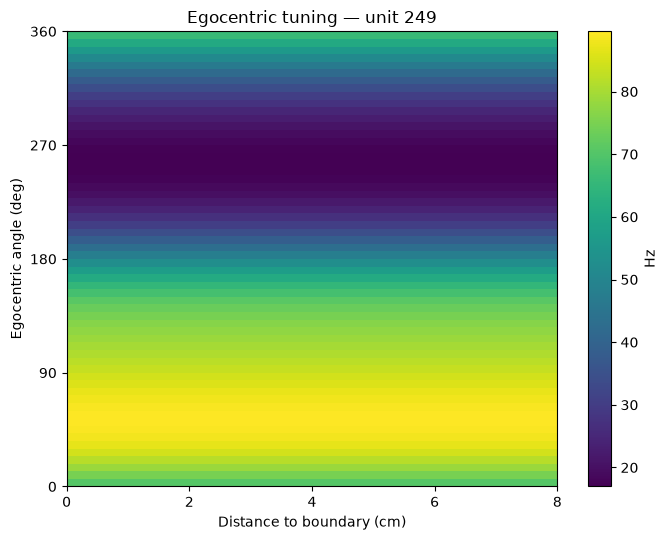

In [3]:
unit_id = 249
is_save = False
save_path = result_path.with_name(f"unit_{unit_id}.png")


rfmap = rf_maps.by_unit_id(unit_id)
# The RFMap helper shows immediately; defer display until the spatial labels are set.
with plt.rc_context({**LIGHT_PLOT_STYLE, "figure.figsize": (7, 5.5)}), capture_output():
    figure, axis = plot_2d_rfmap(rfmap.to_2d_array())

distance_edges = rfmap.metadata["xBinEdges"]
theta_edges = rfmap.metadata["yBinEdges"]
axis.images[0].set_extent((
    distance_edges[0], distance_edges[-1], theta_edges[-1], theta_edges[0],
))
axis.set_ylim(theta_edges[0], theta_edges[-1])
axis.set_aspect("auto")
axis.set_xticks(np.linspace(distance_edges[0], distance_edges[-1], 5))
axis.set_yticks(np.linspace(theta_edges[0], theta_edges[-1], 5))
axis.set_xlabel("Distance to boundary (cm)")
axis.set_ylabel("Egocentric angle (deg)")
axis.set_title(f"Egocentric tuning — unit {unit_id}")
figure.axes[1].set_ylabel(rfmap.metadata["responseUnits"])
figure.tight_layout()

if is_save:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(save_path, dpi=300, facecolor="white", transparent=False)
display(figure)
plt.close(figure)


## Units with data: 1D angular heatmap

First filter out all-zero or entirely missing units; `excluded_unit_ids` records the omitted IDs. Then sum over distance, normalize, and sort using the same native-bin peaks and 180 → 90 → 0 → 270 → 180 layout as the RF heatmaps in `hd_rf_comparison.ipynb` (breaking ties by unit ID). Both notebooks use `Utils.plotting.plot_keyed_heatmap` for normalization and rendering. Axis labels are recorded Kilosort unit IDs.


Plotting 60/159 units; excluded 99 all-zero or missing profiles (excluded_unit_ids).


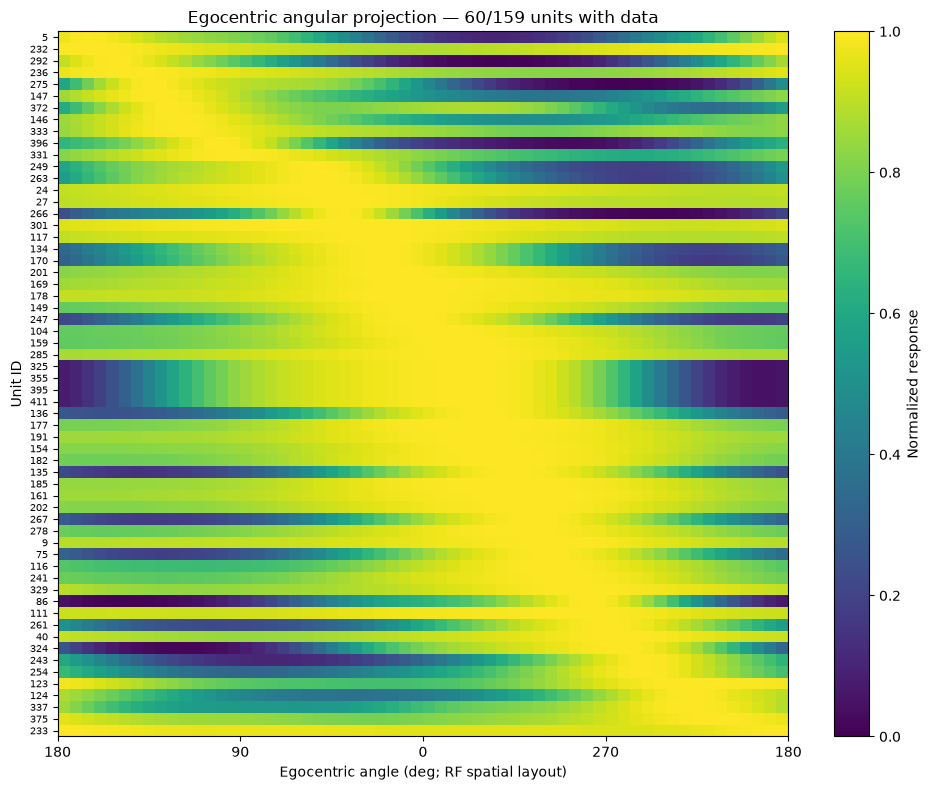

In [4]:
is_save_heatmap = False
heatmap_path = result_path.with_name("all_units_angle_heatmap.png")

rate_maps = rf_maps.to_2d_array()
unit_ids = np.asarray(rf_maps.unit_ids)
# Filter first, keeping each unit ID aligned with its retained matrix.
not_zero = np.any(np.isfinite(rate_maps) & (rate_maps != 0), axis=(1, 2))
excluded_unit_ids = unit_ids[~not_zero]
unit_ids = unit_ids[not_zero]
rate_maps = rate_maps[not_zero]

# Sum over distance, as in an RFMap y projection; unvisited bins stay missing.
angle_profiles = np.nansum(rate_maps, axis=2)
angle_profiles[~np.isfinite(rate_maps).any(axis=2)] = np.nan

# Use the same angular layout and peak ordering as hd_rf_comparison.ipynb.
angle_x = -((rf_maps[0].y_positions + 180.0) % 360.0 - 180.0)
column_order = np.argsort(angle_x)
# Match RF sorting: take the native-bin peak before changing display order.
peak_bin = np.argmax(np.where(np.isfinite(angle_profiles), angle_profiles, -np.inf), axis=1)
unit_order = np.lexsort((unit_ids, angle_x[peak_bin]))
sorted_unit_ids = unit_ids[unit_order]
n_units = len(unit_order)
print(
    f"Plotting {n_units}/{len(rf_maps)} units; "
    f"excluded {len(excluded_unit_ids)} all-zero or missing profiles (excluded_unit_ids)."
)

profile_by_unit_id = dict(zip(unit_ids, angle_profiles, strict=True))
heatmap_figure, heatmap_axis = plot_keyed_heatmap(
    profile_by_unit_id, sorted_unit_ids,
    column_order=column_order,
    xticks=(-180, -90, 0, 90, 180), xticklabels=(180, 90, 0, 270, 180),
    xlabel="Egocentric angle (deg; RF spatial layout)",
    title=f"Egocentric angular projection — {n_units}/{len(rf_maps)} units with data",
    show=False,
    empty_message="No nonzero responses in this RFMap.",
)
heatmap_axis.tick_params(axis="y", labelsize=7)

if is_save_heatmap:
    heatmap_path.parent.mkdir(parents=True, exist_ok=True)
    heatmap_figure.savefig(heatmap_path, dpi=300, facecolor="white", transparent=False)
display(heatmap_figure)
plt.close(heatmap_figure)
